In [86]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from particle import Particle

In [87]:
file = uproot.open("../full_Hsphere/MuravesSim_Data_20260310_113155.root")
#print(file.keys())

gen_tree = file["PrimaryGenData"]
gen_data = gen_tree.arrays(["Event", "GenPartID", "GenPartPDG", "GenPartE", "GenPartTheta", "GenPartPhi"], 
                            aliases = {"event": "Event",
                                       "track_id": "nGenPartID",
                                       "pdg":    "GenPartPDG",
                                        "energy": "GenPartE",
                                        "theta":  "GenPartTheta",
                                        "phi":    "GenPartPhi",
                                        },                           
                            library="ak")

hit_tree = file["HitData"]
hit_data = hit_tree.arrays(["Event", "NScintHit", "ScintHitParentID", "ScintHitE", 
                        "ScintHitPosX", "ScintHitPosY", "ScintHitPosZ", 
                        "ScintHitStation", "ScintHitModule", "ScintHitBar", 
                        "ScintHitPDG", "ScintHitTrackID"],
                        aliases={
                            "event":      "Event",
                            "n_hits":     "NScintHit",
                            "parent_id":  "ScintHitParentID",
                            "hit_energy":     "ScintHitE",
                            "x":          "ScintHitPosX",
                            "y":          "ScintHitPosY",
                            "z":          "ScintHitPosZ",
                            "station":    "ScintHitStation",
                            "module":     "ScintHitModule",
                            "bar":        "ScintHitBar",
                            "pdg":        "ScintHitPDG",
                            "track_id":   "ScintHitTrackID",
                        },                          
                        library="ak")

In [88]:
hit_event_ids = hit_data["Event"]
#_, counts = np.unique(ak.to_numpy(hit_event_ids), return_counts=True) # number of hits per event

counts = pd.Series(hit_event_ids).value_counts().sort_index().values # number of hits per event

# make jagged array (unflatten)
hit_jagged = ak.zip({
    "hit_energy":   ak.unflatten(hit_data["ScintHitE"],      counts),
    "x":        ak.unflatten(hit_data["ScintHitPosX"],   counts),
    "y":        ak.unflatten(hit_data["ScintHitPosY"],   counts),
    "z":        ak.unflatten(hit_data["ScintHitPosZ"],   counts),
    "station":  ak.unflatten(hit_data["ScintHitStation"],counts),
    "module":   ak.unflatten(hit_data["ScintHitModule"], counts),
    "bar":      ak.unflatten(hit_data["ScintHitBar"],    counts),
    "pdg":      ak.unflatten(hit_data["ScintHitPDG"],    counts),
    "track_id": ak.unflatten(hit_data["ScintHitTrackID"],counts),
    "parent_id":ak.unflatten(hit_data["ScintHitParentID"],counts),
})

In [89]:
# Total energy deposited per event
#edep_per_event = ak.sum(hit_data["ScintHitE"], axis=1)
edep_per_event = ak.sum(hit_jagged["hit_energy"], axis=1)

In [90]:
hit_df = hit_tree.arrays(
    ["Event", "ScintHitBar", "ScintHitModule", "ScintHitStation", "ScintHitE", "ScintHitPDG"],
    library="pd"   # load as pandas dataframe
)
hit_df.columns = ["event", "bar", "module", "station", "energy", "pdg"]

In [91]:
# Energy per bar per event
edep_bar     = hit_df.groupby(["event", "bar"])["energy"].sum()
edep_bar.columns = ["event", "bar", "edep"]

# Energy per module per event
edep_module  = hit_df.groupby(["event", "module"])["energy"].sum()

# Energy per station per event
edep_station = hit_df.groupby(["event", "station"])["energy"].sum()

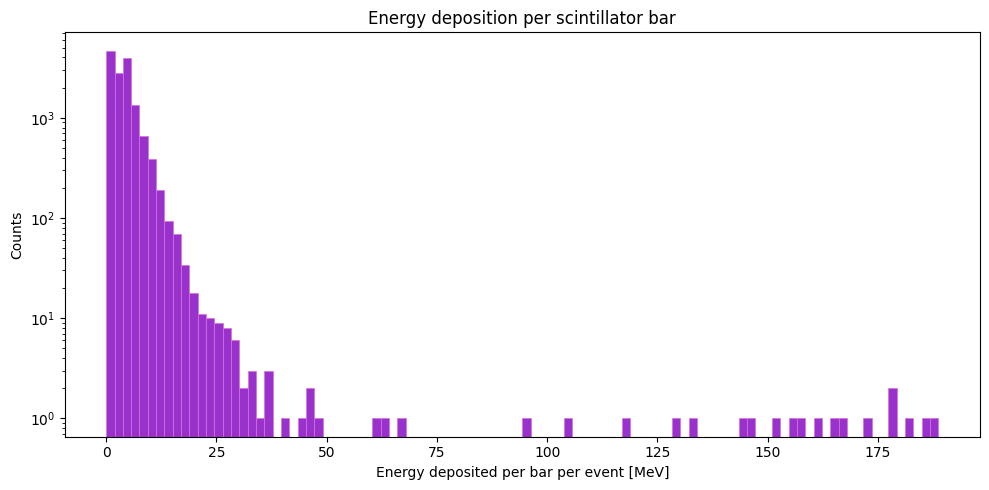

In [120]:
plt.figure(figsize=(10, 5))
plt.hist(edep_bar.values, bins=100, color="darkorchid", edgecolor="orchid", linewidth=0.5)
plt.xlabel("Energy deposited per bar per event [MeV]")
plt.ylabel("Counts")
plt.yscale("log")  # useful if dynamic range is large
plt.title("Energy deposition per scintillator bar")
plt.tight_layout()
plt.show()

In [93]:
# Count hits per PDG code
pdg_counts = hit_df["pdg"].value_counts()
pdg_percent = hit_df["pdg"].value_counts(normalize=True) * 100

# PDG code -> particle name mapping
pdg_names = {
    11:    "e⁻",
    -11:   "e⁺",
    13:    "μ⁻",
    -13:   "μ⁺",
    22:    "γ",
    2212:  "p",
    2112:  "n",
    211:   "π⁺",
    -211:  "π⁻",
    111:   "π⁰",
    321:   "K⁺",
    -321:  "K⁻",
}

print("Particle hit composition:")
print(f"{'PDG':>8}  {'Name':>6}  {'Hits':>8}  {'%':>8}")
print("-" * 36)
for pdg, pct in pdg_percent.items():
    name = pdg_names.get(pdg, "?")
    count = pdg_counts[pdg]
    print(f"{pdg:>8}  {name:>6}  {count:>8}  {pct:>7.2f}%")

Particle hit composition:
     PDG    Name      Hits         %
------------------------------------
      11      e⁻     17351    58.76%
     -13      μ⁺      5713    19.35%
      13      μ⁻      4580    15.51%
      22       γ       688     2.33%
    2112       n       535     1.81%
     -11      e⁺       293     0.99%
    2212       p       287     0.97%
1000060120       ?        67     0.23%
    -211      π⁻         8     0.03%
1000020040       ?         3     0.01%
1000010020       ?         2     0.01%
1000060130       ?         1     0.00%
1000050110       ?         1     0.00%


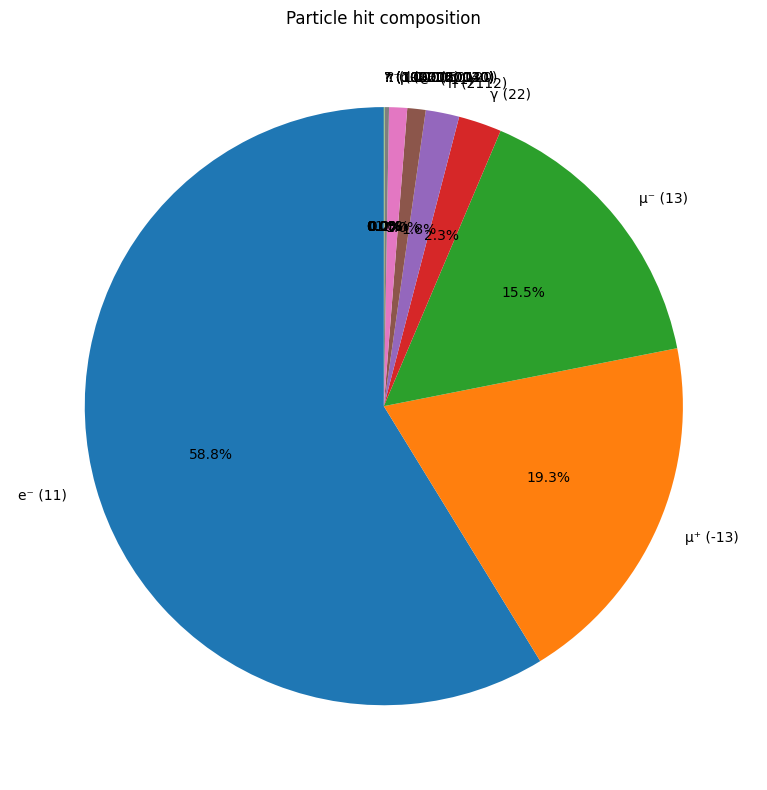

In [ ]:
labels = [f"{pdg_names.get(p, '?')} ({p})" for p in pdg_percent.index]
#labels = [f"{pdg_to_name(p)}" for p in pdg_percent.index]

plt.figure(figsize=(8, 8))
plt.pie(
    pdg_percent.values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Particle hit composition")
plt.tight_layout()
plt.show()

In [ ]:
# Check which PDG codes are in your data
unique_pdgs = hit_df["pdg"].unique()
print("PDG codes in data:", sorted(unique_pdgs))

# Check which ones are missing from your mapping
unknown = [p for p in unique_pdgs if p not in pdg_names]
print("Unmapped PDG codes:", unknown)

for pdg in sorted(unique_pdgs):
    try:
        name = Particle.from_pdgid(pdg).name
    except:
        name = "unknown"
    print(f"PDG {pdg:>8} → {name}")

def pdg_to_name(pdg):
    try:
        return Particle.from_pdgid(pdg).name
    except:
        return f"PDG {pdg}"

PDG codes in data: [np.int32(-211), np.int32(-13), np.int32(-11), np.int32(11), np.int32(13), np.int32(22), np.int32(2112), np.int32(2212), np.int32(1000010020), np.int32(1000020040), np.int32(1000050110), np.int32(1000060120), np.int32(1000060130)]
Unmapped PDG codes: [np.int32(1000060120), np.int32(1000020040), np.int32(1000010020), np.int32(1000060130), np.int32(1000050110)]
PDG     -211 → pi-
PDG      -13 → mu+
PDG      -11 → e+
PDG       11 → e-
PDG       13 → mu-
PDG       22 → gamma
PDG     2112 → n
PDG     2212 → p
PDG 1000010020 → D2
PDG 1000020040 → He4
PDG 1000050110 → B11
PDG 1000060120 → C12
PDG 1000060130 → C13


In [98]:
gen_df = gen_tree.arrays(["Event", "GenPartPhi", "GenPartPDG"], library="pd")

# Classify forward/backward muons by phi quadrant
gen_df = gen_df.copy()
gen_df["direction"] = np.where(
    (gen_df["GenPartPhi"] > -np.pi/2) & (gen_df["GenPartPhi"] < np.pi/2),
    "forward",
    "backward")

print(gen_df["direction"].value_counts())

direction
forward     988
backward    741
Name: count, dtype: int64


In [102]:
directional_hit_df = hit_df.merge(
    gen_df[["Event", "direction"]],
    left_on="event",
    right_on="Event",
    how="inner"
).drop(columns="Event")

print(directional_hit_df.head())

   event  bar  module  station    energy  pdg direction
0   1395   16       0        2  4.292411  -13  backward
1   1395    2       1       10  4.211426  -13  backward
2   1395   20       0        0  4.042369  -13  backward
3   1395   16       0        8  4.619717  -13  backward
4   1395   24       0        1  4.112127  -13  backward


In [107]:
hits_forward  = directional_hit_df[directional_hit_df["direction"] == "forward"]
hits_backward = directional_hit_df[directional_hit_df["direction"] == "backward"]

hits_per_bar_forward  = hits_forward.groupby("bar").size()
hits_per_bar_backward = hits_backward.groupby("bar").size()

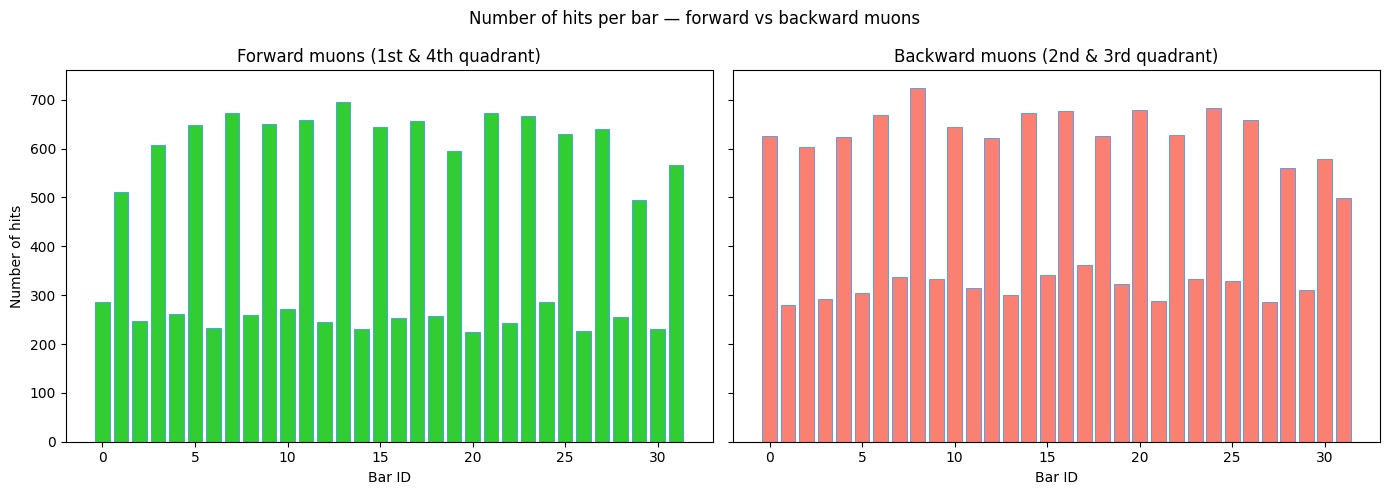

In [ ]:
all_bars = np.union1d(hits_per_bar_forward.index, hits_per_bar_backward.index)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].bar(hits_per_bar_forward.index, hits_per_bar_forward.values, color="limegreen", edgecolor="dodgerblue", linewidth=0.5)
axes[0].set_title("Forward muons")
axes[0].set_xlabel("Bar ID")
axes[0].set_ylabel("Number of hits")

axes[1].bar(hits_per_bar_backward.index, hits_per_bar_backward.values, color="salmon", edgecolor="dodgerblue", linewidth=0.5)
axes[1].set_title("Backward muons")
axes[1].set_xlabel("Bar ID")

plt.suptitle("Number of hits per bar — forward vs backward muons")
plt.tight_layout()
plt.show()

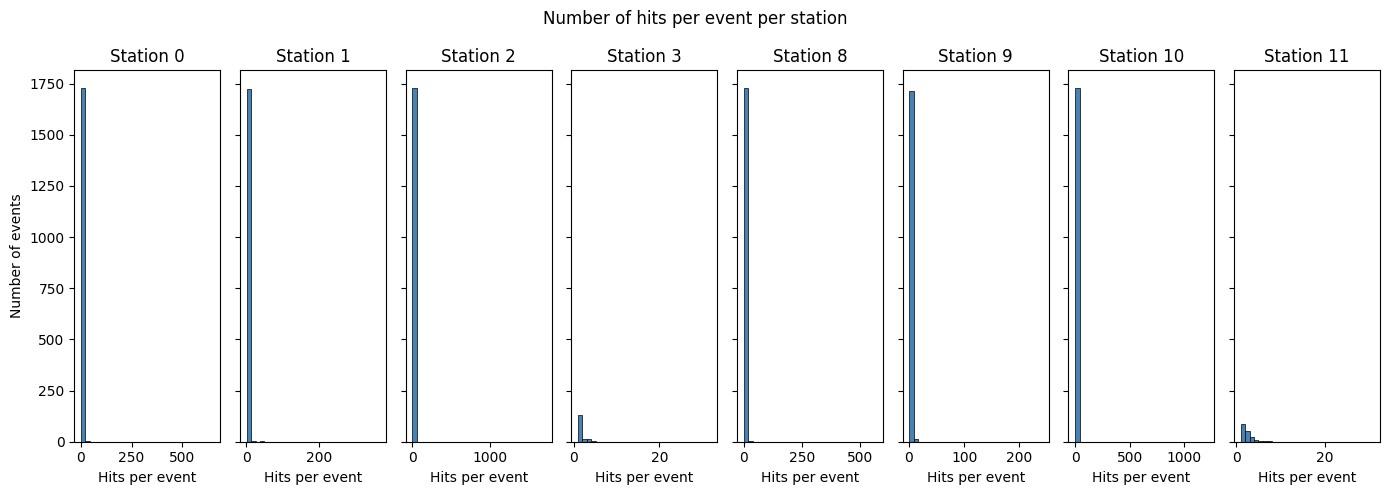

In [124]:
hits_per_event_station = hit_df.groupby(["event", "station"]).size().reset_index(name="nhits")

fig, axes = plt.subplots(1, len(hits_per_event_station["station"].unique()), 
                          figsize=(14, 5), sharey=True)

for ax, (station, group) in zip(axes, hits_per_event_station.groupby("station")):
    ax.hist(group["nhits"], bins=30, color="steelblue", edgecolor="black", linewidth=0.5)
    ax.set_title(f"Station {station}")
    ax.set_xlabel("Hits per event")

axes[0].set_ylabel("Number of events")
plt.suptitle("Number of hits per event per station")
plt.tight_layout()
plt.show()

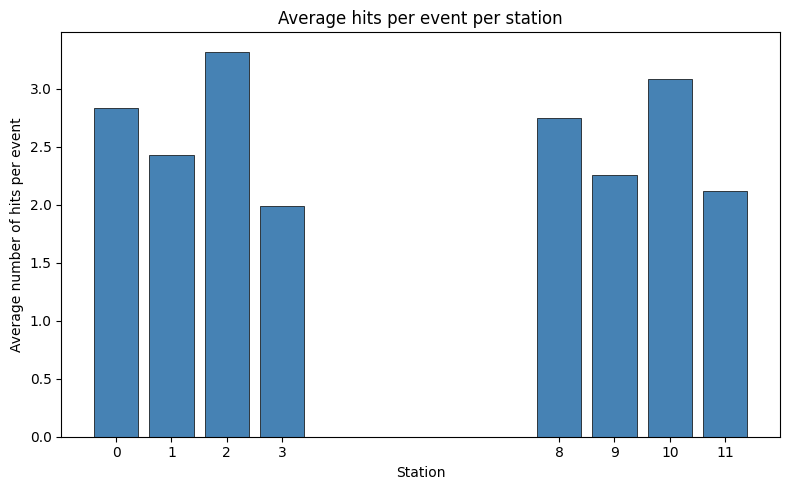

In [126]:
avg_hits_per_station = hit_df.groupby(["event", "station"]).size().groupby("station").mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_hits_per_station.index, avg_hits_per_station.values,
        color="steelblue", edgecolor="black", linewidth=0.5)
plt.xlabel("Station")
plt.ylabel("Average number of hits per event")
plt.title("Average hits per event per station")
plt.xticks(avg_hits_per_station.index)
plt.tight_layout()
plt.show()

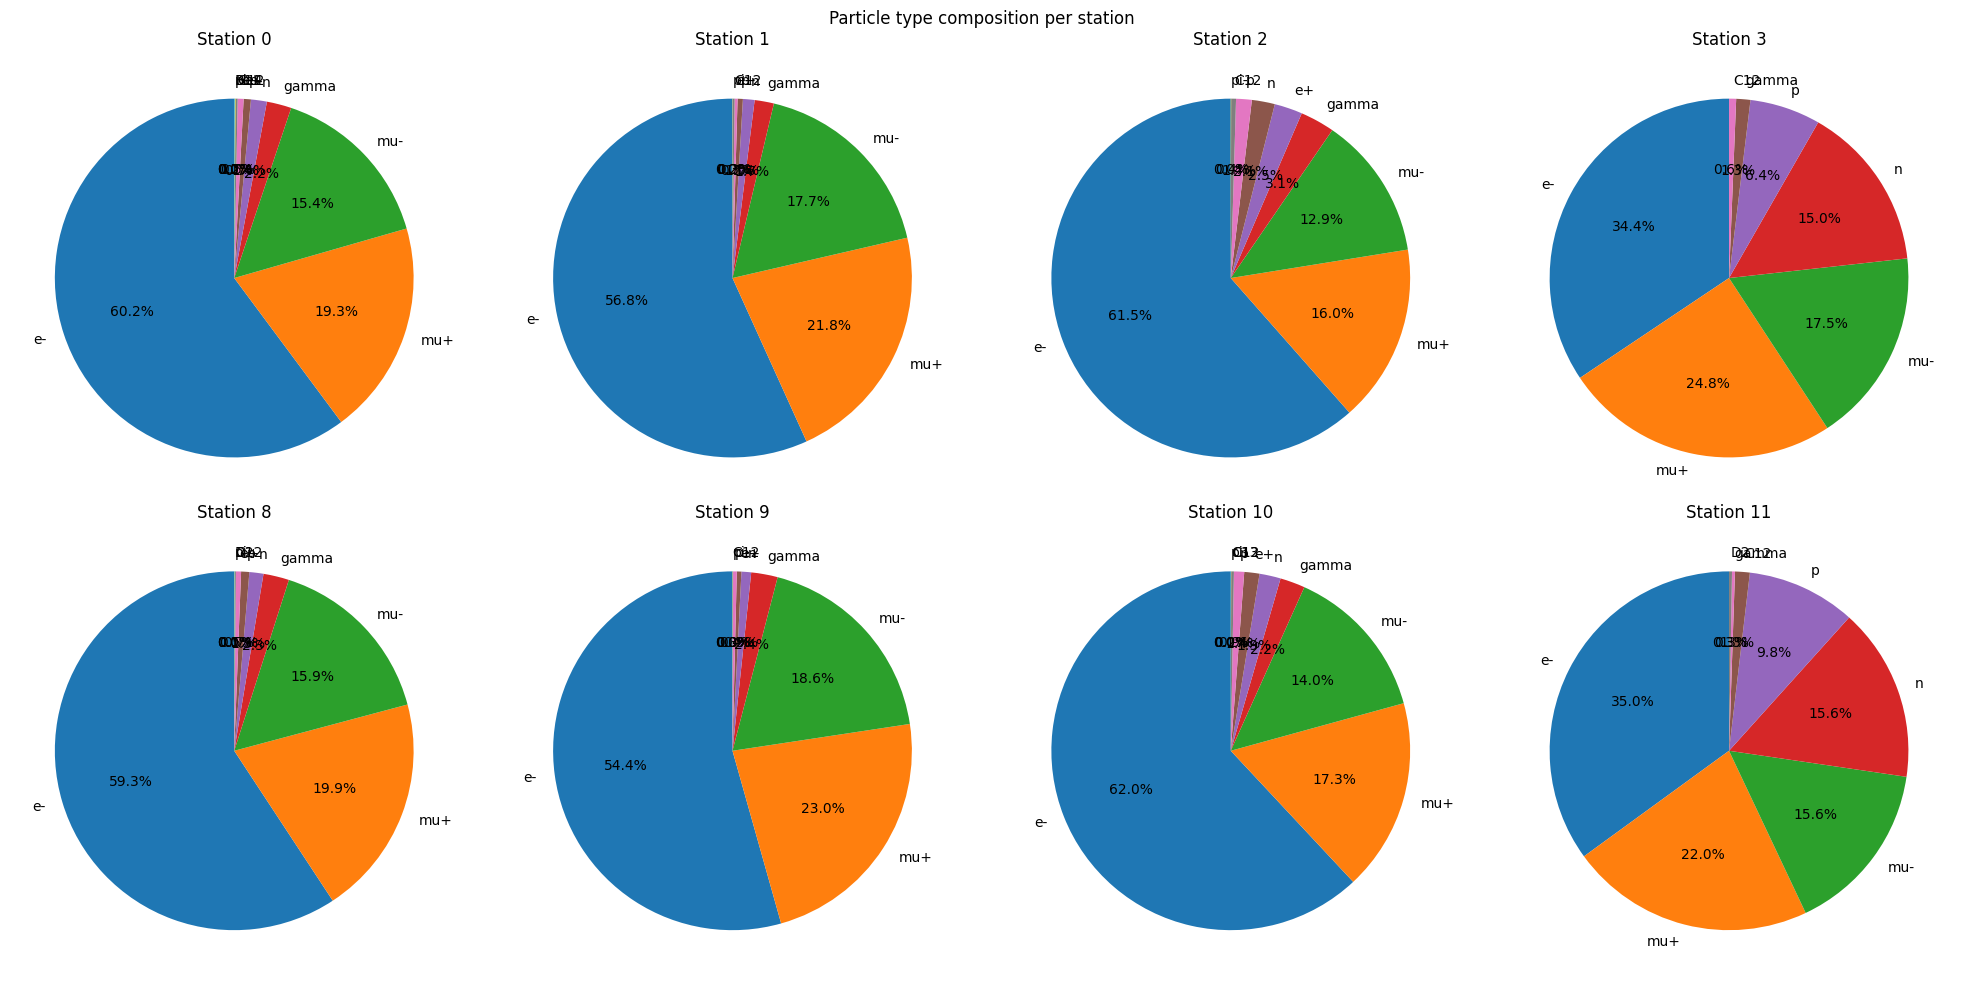

In [128]:
stations = sorted(hit_df["station"].unique())
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, (station, group) in zip(axes, hit_df.groupby("station")):
    pdg_counts = group["pdg"].value_counts()
    labels = [pdg_to_name(p) for p in pdg_counts.index]

    ax.pie(pdg_counts.values, labels=labels, autopct="%1.1f%%", startangle=90)
    ax.set_title(f"Station {station}")

plt.suptitle("Particle type composition per station")
plt.tight_layout()
plt.show()